In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations
from collections import Counter

In [2]:
# Load the datasets
aisles_df = pd.read_csv('../dataraw/aisles.csv')
departments_df = pd.read_csv('../dataraw/departments.csv')
order_prior_df = pd.read_csv('../dataraw/order_products_prior.csv')
order_train_df = pd.read_csv('../dataraw/order_products_train.csv')
orders_df = pd.read_csv('../dataraw/orders.csv')
products_df = pd.read_csv('../dataraw/products.csv')

# Explore the data

In [3]:
# Aisles DataFrame
print("Aisles DataFrame:")
print(aisles_df.head())
print("\nAisles DataFrame Info:")
print(aisles_df.info())

Aisles DataFrame:
   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation

Aisles DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
None


In [4]:
# Departments DataFrame
print("\nDepartments DataFrame:")
print(departments_df.head())
print("\nDepartments DataFrame Info:")
print(departments_df.info())


Departments DataFrame:
   department_id department
0              1     frozen
1              2      other
2              3     bakery
3              4    produce
4              5    alcohol

Departments DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes
None


In [5]:
# Order_products__prior DataFrame
print("\nOrder_products__prior DataFrame:")
print(order_prior_df.head())
print("\nOrder_products__prior DataFrame Info:")
print(order_prior_df.info())


Order_products__prior DataFrame:
   order_id  product_id  add_to_cart_order  reordered
0         2       33120                  1          1
1         2       28985                  2          1
2         2        9327                  3          0
3         2       45918                  4          1
4         2       30035                  5          0

Order_products__prior DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 989.8 MB
None


In [6]:
# Order_products__train DataFrame
print("\nOrder_products__train DataFrame:")
print(order_train_df.head())
print("\nOrder_products__train DataFrame Info:")
print(order_train_df.info())


Order_products__train DataFrame:
   order_id  product_id  add_to_cart_order  reordered
0         1       49302                  1          1
1         1       11109                  2          1
2         1       10246                  3          0
3         1       49683                  4          0
4         1       43633                  5          1

Order_products__train DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   order_id           1384617 non-null  int64
 1   product_id         1384617 non-null  int64
 2   add_to_cart_order  1384617 non-null  int64
 3   reordered          1384617 non-null  int64
dtypes: int64(4)
memory usage: 42.3 MB
None


In [7]:
# Orders DataFrame
print("\nOrders DataFrame:")
print(orders_df.head())
print("\nOrders DataFrame Info:")
print(orders_df.info())


Orders DataFrame:
   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   
3   2254736        1    prior             4          4                  7   
4    431534        1    prior             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
3                    29.0  
4                    28.0  

Orders DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            

In [8]:
# Products DataFrame
print("\nProducts DataFrame:")
print(products_df.head())
print("\nProducts DataFrame Info:")
print(products_df.info())


Products DataFrame:
   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  

Products DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49688 non-null  int64 
 1   product_name   49688 non-null  object
 2   aisle_id       49688 non-null  int64 
 3   department_id  49688 non-null  int64 
dtyp

# cleaning

In [9]:
orders_df['days_since_prior_order'].fillna(0, inplace=True)

In [10]:
orders_df['days_since_prior_order'] = orders_df['days_since_prior_order'].astype(int)

# Visualize the data

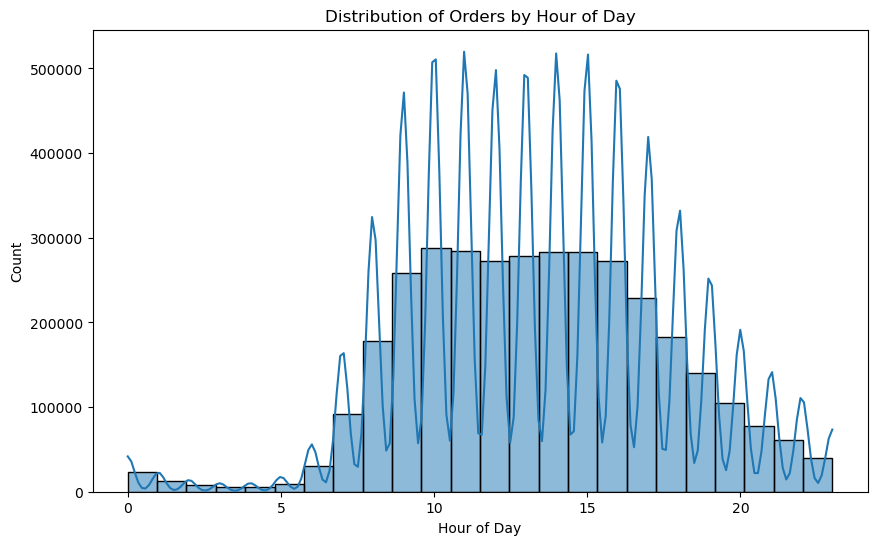

In [11]:
# Example: Plot histogram of 'order_hour_of_day' in Orders DataFrame
plt.figure(figsize=(10, 6))
sns.histplot(orders_df['order_hour_of_day'], bins=24, kde=True)
plt.title('Distribution of Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.show()

In [12]:
# Calculate descriptive statistics
# Summary statistics for 'days_since_prior_order' in Orders DataFrame
print("\nDescriptive Statistics for 'days_since_prior_order' in Orders DataFrame:")
print(orders_df['days_since_prior_order'].describe())


Descriptive Statistics for 'days_since_prior_order' in Orders DataFrame:
count    3.421083e+06
mean     1.044488e+01
std      9.308727e+00
min      0.000000e+00
25%      4.000000e+00
50%      7.000000e+00
75%      1.500000e+01
max      3.000000e+01
Name: days_since_prior_order, dtype: float64


In [13]:
# Summary statistics for 'add_to_cart_order' in Order_products__prior DataFrame
print("\nDescriptive Statistics for 'add_to_cart_order' in Order_products__prior DataFrame:")
print(order_prior_df['add_to_cart_order'].describe())


Descriptive Statistics for 'add_to_cart_order' in Order_products__prior DataFrame:
count    3.243449e+07
mean     8.351076e+00
std      7.126671e+00
min      1.000000e+00
25%      3.000000e+00
50%      6.000000e+00
75%      1.100000e+01
max      1.450000e+02
Name: add_to_cart_order, dtype: float64


In [14]:
# Summary statistics for 'reordered' in Order_products__train DataFrame
print("\nDescriptive Statistics for 'reordered' in Order_products__train DataFrame:")
print(order_train_df['reordered'].describe())


Descriptive Statistics for 'reordered' in Order_products__train DataFrame:
count    1.384617e+06
mean     5.985944e-01
std      4.901829e-01
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: reordered, dtype: float64


In [15]:
# Generate insights
# Distribution of 'aisle_id' in Products DataFrame
aisle_counts = products_df['aisle_id'].value_counts()
print("\nDistribution of Aisle IDs in Products DataFrame:")
print(aisle_counts)


Distribution of Aisle IDs in Products DataFrame:
100    1258
45     1246
37     1091
47     1038
120    1026
       ... 
113      47
82       44
32       32
68       26
18       12
Name: aisle_id, Length: 134, dtype: int64


In [16]:
# Distribution of 'department_id' in Products DataFrame
department_counts = products_df['department_id'].value_counts()
print("\nDistribution of Department IDs in Products DataFrame:")
print(department_counts)


Distribution of Department IDs in Products DataFrame:
11    6563
19    6264
13    5371
7     4365
1     4007
16    3449
17    3085
15    2092
9     1858
4     1684
3     1516
20    1322
21    1258
6     1139
14    1115
18    1081
5     1054
8      972
12     907
2      548
10      38
Name: department_id, dtype: int64
